## 1. Loading csv files from data folder

In [1]:
import pandas as pd
from pathlib import Path

data_dir = Path("../data/raw")  # relative to the notebook folder

customers = pd.read_csv(data_dir / "customers.csv")
order_items = pd.read_csv(data_dir / "order_items.csv")
orders = pd.read_csv(data_dir / "orders.csv")
products = pd.read_csv(data_dir / "products.csv")


There are four different files in the dataset: customers.csv, order_items.csv, orders.csv, and products.csv

In [2]:
customers.head()

,customer_id,gender,first_name,last_name,full_name,age,city,signup_date
0,0,Female,Riya,Malhotra,Riya Malhotra,19.0,Pune,2024-09-30
1,1,Male,Suresh,Gupta,Suresh Gupta,27.0,Hyderabad,2025-11-13
2,2,Male,Amit,Reddy,Amit Reddy,37.0,Bangalore,2023-04-18
3,3,Male,Rohit,Malhotra,Rohit Malhotra,59.0,Pune,2024-12-28
4,4,Female,Neha,Iyer,Neha Iyer,56.0,Delhi,2024-08-19


In [3]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount,net_amount
0,Byk-0,6514,3,3614.06,275.99,10566.19
1,Byk-0,2222,4,4539.08,1090.19,17066.13
2,Byk-0,40137,4,85.64,12.91,329.65
3,Byk-1,48440,3,1384.96,317.69,3837.19
4,Byk-1,52122,1,3002.00,108.78,2893.22


In [4]:
orders.head()

,order_id,customer_id,order_date,order_ts,city,state,payment_method,order_status,total_amount
0,Byk-0,651198,2025-11-20,2025-11-20T16:38:56.000Z,Delhi,DL,Wallet,Cancelled,1755.48
1,Byk-1,192749,2025-12-07,2025-12-07T12:24:38.000Z,Pune,MH,Debit Card,Delivered,6055.63
2,Byk-2,217349,2025-04-10,2025-04-10T23:41:58.000Z,Chennai,TN,Credit Card,Delivered,1413.51
3,Byk-3,405295,2025-10-31,2025-10-31T13:24:18.000Z,Delhi,DL,COD,Delivered,3157.44
4,Byk-4,93506,2025-06-21,2025-06-21T19:14:54.000Z,Kolkata,WB,Debit Card,Delivered,4219.23


In [5]:
products.head()

,product_id,brand,category,sub_category,mrp
0,0,Nykaa Naturals,Fragrance,Compact,4833.00
1,1,Lakme,Personal Care,Serum,710.60
2,2,Nykaa Naturals,Personal Care,Eyeliner,3217.86
3,3,WOW Skin Science,Skincare,Sanitizer,4979.63
4,4,Lakme,Haircare,Soap,347.29


## 2. Counting of **MISSING VALUE** for each file

In [6]:
for name, df in [
    ("customers", customers),
    ("order_items", order_items),
    ("orders", orders),
    ("products", products),
]:
    print(f"{name} missing values:")
    print(df.isna().sum())
    print()

customers missing values:
customer_id        0
gender         20059
first_name     10045
last_name       9978
full_name      19933
age            19960
city           19776
signup_date        0
dtype: int64

order_items missing values:
order_id          0
product_id        0
quantity          0
unit_price        0
discount      29984
net_amount        0
dtype: int64

orders missing values:
order_id              0
customer_id           0
order_date            0
order_ts              0
city              19844
state             19993
payment_method    29888
order_status       9934
total_amount          0
dtype: int64

products missing values:
product_id         0
brand           5135
category        5106
sub_category    5066
mrp             2946
dtype: int64



### 2.1. **customers** table

#### 2.1.1. Handling the missing values in **customers** table

In [7]:
# fill full_name when missing (from first_name + last_name)
mask = customers["full_name"].isna()
customers.loc[mask, "full_name"] = (
    customers.loc[mask, "first_name"].fillna("") + " " + customers.loc[mask, "last_name"].fillna("")
).str.strip()
customers.loc[customers["full_name"] == "", "full_name"] = pd.NA

# fill missing gender as "U"
customers["gender"] = customers["gender"].fillna("U")

# if age has NaNs, use pandas nullable integer dtype
customers["age"] = customers["age"].astype("Int64")

customers.isna().sum()

customer_id        0
gender             0
first_name     10045
last_name       9978
full_name         90
age            19960
city           19776
signup_date        0
dtype: int64

In [8]:
mask = customers["first_name"].isna() & customers["last_name"].isna()

customers.loc[mask, "first_name"] = "unknown"
customers.loc[mask, "last_name"] = "unknown"
customers.loc[mask, "full_name"] = "Unknown"

# if you also want to fill any remaining "full_name" gaps globally
customers["full_name"] = customers["full_name"].fillna("Unknown")

customers[mask]

,customer_id,gender,first_name,last_name,full_name,age,city,signup_date
2887,2887,Female,unknown,unknown,Unknown,22,Chennai,2024-06-17
6337,6337,Male,unknown,unknown,Unknown,40,Delhi,2025-11-12
9013,9013,Male,unknown,unknown,Unknown,31,Hyderabad,2024-11-17
42842,42842,Female,unknown,unknown,Unknown,20,Pune,2023-10-24
55723,55723,Female,unknown,unknown,Unknown,33,Kolkata,2022-08-18
...,...,...,...,...,...,...,...,...
950487,950487,Female,unknown,unknown,Unknown,27,Chennai,2025-12-23
951124,951124,Female,unknown,unknown,Unknown,53,Bangalore,2023-09-10
958045,958045,Male,unknown,unknown,Unknown,45,NaN,2025-02-20
963014,963014,Male,unknown,unknown,Unknown,35,Bangalore,2023-09-06


Map cities between **customers** and **orders** by *customer_id*

In [9]:

# map cities between customers and orders by customer_id
cust_city = customers.set_index("customer_id")["city"]

# fill missing in orders from customers
mask = orders["city"].isna() & orders["customer_id"].notna()
orders.loc[mask, "city"] = orders.loc[mask, "customer_id"].map(cust_city)

# infer customer city from orders when missing in customers
orders_city_by_customer = (
    orders[orders["city"].notna()]
    .groupby("customer_id")["city"]
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else None)
)
mask = customers["city"].isna() & customers["customer_id"].notna()
customers.loc[mask, "city"] = customers.loc[mask, "customer_id"].map(orders_city_by_customer)



In [10]:
# final fallback
customers["city"] = customers["city"].fillna("unknown")
customers["first_name"] = customers["first_name"].fillna("unknown")
customers["last_name"] = customers["last_name"].fillna("unknown")

#### 2.1.2. Find and Drop the **duplicates** in customer table

In [11]:
# find duplicates by customer_id (or by all columns)
dups_by_id = customers[customers.duplicated(subset=["customer_id"], keep=False)]
dups_full = customers[customers.duplicated(keep=False)]

print("duplicates by customer_id:", len(dups_by_id))
print("full-row duplicates:", len(dups_full))

# inspect a few
dups_by_id.head()
dups_full.head()

# drop duplicates (keep first occurrence)
customers = customers.drop_duplicates(subset=["customer_id"], keep="first").reset_index(drop=True)

# (optional) if you want to drop only exact full-row duplicates:
# customers = customers.drop_duplicates(keep="first").reset_index(drop=True)

duplicates by customer_id: 0
full-row duplicates: 0


In [12]:
customers.isna().sum()

customer_id        0
gender             0
first_name         0
last_name          0
full_name          0
age            19960
city               0
signup_date        0
dtype: int64

### 2.2. **order_items** table

### 2.2.1. Handling the missing values in **order_items** table

In [13]:
# fill missing discount = net_amount - unit_price * quantity
mask = order_items["discount"].isna()
order_items.loc[mask, "discount"] = abs(
    order_items.loc[mask, "net_amount"]
    - order_items.loc[mask, "unit_price"] * order_items.loc[mask, "quantity"]
)

order_items.isna().sum()

order_id      0
product_id    0
quantity      0
unit_price    0
discount      0
net_amount    0
dtype: int64

In [14]:

# Remove any commas, spaces, or percent signs from numeric columns
for col in ["unit_price", "discount", "net_amount"]:
    order_items[col] = (
        order_items[col]
        .astype(str)                     # Ensure string first
        .str.replace(",", "", regex=False)  # Remove commas
        .str.replace("%", "", regex=False)  # Remove percent
        .str.strip()                     # Remove leading/trailing spaces
    )
    # Convert to float, invalid values become NaN
    order_items[col] = pd.to_numeric(order_items[col], errors="coerce").round(2)

# Convert integer columns safely
order_items["quantity"] = pd.to_numeric(order_items["quantity"], errors="coerce").astype("Int64")
order_items["product_id"] = pd.to_numeric(order_items["product_id"], errors="coerce").astype("Int64")

# Convert order_id to string
order_items["order_id"] = order_items["order_id"].astype(str)

# Optional: fill NaNs with 0
order_items[["discount", "net_amount", "unit_price"]] = order_items[["discount", "net_amount", "unit_price"]].fillna(0)


In [15]:
print(order_items.dtypes)

order_id       object
product_id      Int64
quantity        Int64
unit_price    float64
discount      float64
net_amount    float64
dtype: object


### 2.2.2. Handling the duplicates in **order_items** table

In [16]:
# find duplicates in order_items (by key columns or full row)
dups_by_key = order_items[order_items.duplicated(subset=["order_id", "product_id"], keep=False)]
dups_full = order_items[order_items.duplicated(keep=False)]

print("duplicates by (order_id, product_id):", len(dups_by_key))
print("full-row duplicates:", len(dups_full))

# inspect a few
dups_by_key.head()
dups_full.head()

# drop duplicates (keep first occurrence)
order_items = order_items.drop_duplicates(subset=["order_id", "product_id"], keep="first").reset_index(drop=True)

# (or, if you want to drop only exact full-row duplicates:)
# order_items = order_items.drop_duplicates(keep="first").reset_index(drop=True)

duplicates by (order_id, product_id): 0
full-row duplicates: 0


### 2.3 **orders** table

### 2.3.1. Handling the missing values in **orders** table

In [17]:
orders.isna().sum()

order_id              0
customer_id           0
order_date            0
order_ts              0
city                382
state             19993
payment_method    29888
order_status       9934
total_amount          0
dtype: int64

In [18]:
# unique cities per state in orders
cities_by_state = (
    orders[["state", "city"]]
    .drop_duplicates()
    .sort_values(["state", "city"])
)

cities_by_state.head(50)  # or `cities_by_state` to view all

,state,city
0,DL,Delhi
17,KA,Bangalore
6,MH,Mumbai
1,MH,Pune
2,TN,Chennai
9,TS,Hyderabad
48,WB,Bangalore
45,WB,Chennai
49,WB,Delhi
247,WB,Hyderabad


In [19]:
# build fill maps from existing (state, city) pairs
valid = orders.dropna(subset=["state", "city"])

# most common state for each city
city_to_state = valid.groupby("city")["state"].agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)

# most common city for each state
state_to_city = valid.groupby("state")["city"].agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)

# fill when one is missing
mask_state_missing = orders["state"].isna() & orders["city"].notna()
orders.loc[mask_state_missing, "state"] = orders.loc[mask_state_missing, "city"].map(city_to_state)

mask_city_missing = orders["city"].isna() & orders["state"].notna()
orders.loc[mask_city_missing, "city"] = orders.loc[mask_city_missing, "state"].map(state_to_city)


orders.isna().sum()

order_id              0
customer_id           0
order_date            0
order_ts              0
city                  9
state                 9
payment_method    29888
order_status       9934
total_amount          0
dtype: int64

In [20]:
# unique cities per state in orders
cities_by_state = (
    orders[["state", "city"]]
    .drop_duplicates()
    .sort_values(["state", "city"])
)

cities_by_state.head(50)  # or `cities_by_state` to view all

,state,city
0,DL,Delhi
17,KA,Bangalore
6,MH,Mumbai
1,MH,Pune
2,TN,Chennai
9,TS,Hyderabad
48,WB,Bangalore
45,WB,Chennai
49,WB,Delhi
247,WB,Hyderabad


In [21]:
# if payment_method is missing, mark unknown
mask_both_missing = orders["payment_method"].isna()
orders.loc[mask_both_missing, ["payment_method"]] = "Other"

if both "state", "city" are missing, mark unknown

In [22]:
mask_both_missing = orders["state"].isna() & orders["city"].isna()
orders.loc[mask_both_missing, ["state", "city"]] = "unknown"

In [23]:
# if order_status is missing, mark Nonupdated
mask_both_missing = orders["order_status"].isna()
orders.loc[mask_both_missing, ["order_status"]] = "Nonupdated"

orders.isna().sum()

order_id          0
customer_id       0
order_date        0
order_ts          0
city              0
state             0
payment_method    0
order_status      0
total_amount      0
dtype: int64

In [24]:
orders.head()

,order_id,customer_id,order_date,order_ts,city,state,payment_method,order_status,total_amount
0,Byk-0,651198,2025-11-20,2025-11-20T16:38:56.000Z,Delhi,DL,Wallet,Cancelled,1755.48
1,Byk-1,192749,2025-12-07,2025-12-07T12:24:38.000Z,Pune,MH,Debit Card,Delivered,6055.63
2,Byk-2,217349,2025-04-10,2025-04-10T23:41:58.000Z,Chennai,TN,Credit Card,Delivered,1413.51
3,Byk-3,405295,2025-10-31,2025-10-31T13:24:18.000Z,Delhi,DL,COD,Delivered,3157.44
4,Byk-4,93506,2025-06-21,2025-06-21T19:14:54.000Z,Kolkata,WB,Debit Card,Delivered,4219.23


* Convert *order_ts* to datetime and format neatly

In [25]:

orders['order_ts'] = pd.to_datetime(orders['order_ts']).dt.strftime('%Y-%m-%d %H:%M')

print("Converted order_ts sample:")
print(orders[['order_id', 'order_date', 'order_ts']].head())

Converted order_ts sample:
  order_id  order_date          order_ts
0    Byk-0  2025-11-20  2025-11-20 16:38
1    Byk-1  2025-12-07  2025-12-07 12:24
2    Byk-2  2025-04-10  2025-04-10 23:41
3    Byk-3  2025-10-31  2025-10-31 13:24
4    Byk-4  2025-06-21  2025-06-21 19:14


### 2.3.2. Handling the duplicates in **orders** table

In [26]:
# find duplicates by order_id (or by all columns)
dups_by_id = orders[orders.duplicated(subset=["order_id"], keep=False)]
dups_full = orders[orders.duplicated(keep=False)]

print("duplicates by order_id:", len(dups_by_id))
print("full-row duplicates:", len(dups_full))

# inspect a few
dups_by_id.head()
dups_full.head()

# drop duplicates (keep first occurrence)
orders = orders.drop_duplicates(subset=["order_id"], keep="first").reset_index(drop=True)

# (or, if you want to drop only exact full-row duplicates:)
# orders = orders.drop_duplicates(keep="first").reset_index(drop=True)

duplicates by order_id: 0
full-row duplicates: 0


### 2.4. **products** table

In [27]:
products.head()

,product_id,brand,category,sub_category,mrp
0,0,Nykaa Naturals,Fragrance,Compact,4833.00
1,1,Lakme,Personal Care,Serum,710.60
2,2,Nykaa Naturals,Personal Care,Eyeliner,3217.86
3,3,WOW Skin Science,Skincare,Sanitizer,4979.63
4,4,Lakme,Haircare,Soap,347.29


In [28]:
products.isna().sum()

product_id         0
brand           5135
category        5106
sub_category    5066
mrp             2946
dtype: int64

In [29]:
# Standardize product categories based on subcategories
sub_to_standard_cat = {
    'Compact': 'Makeup',
    'Serum': 'Skincare',
    'Eyeliner': 'Makeup',
    'Sanitizer': 'Personal Care',
    'Soap': 'Personal Care',
    'Face Wash': 'Skincare',
    'Sunscreen': 'Skincare',
    'Oil': 'Skincare',
    'Perfume': 'Fragrance',
    'Handwash': 'Personal Care',
    'Hair Mask': 'Haircare',
    'Deodorant': 'Fragrance',
    'Mask': 'Skincare',
    'Mascara': 'Makeup',
    'Foundation': 'Makeup',
    'Moisturizer': 'Skincare',
    'Conditioner': 'Haircare',
    'Lipstick': 'Makeup',
    'Body Mist': 'Fragrance',
    'Shampoo': 'Haircare',
    'Body Lotion': 'Personal Care',
    'other': 'Other'
}

# Apply the mapping
products['category'] = products['sub_category'].map(sub_to_standard_cat).fillna('Other')

print("Updated unique categories:", products['category'].unique())
print("\nSample products:")
print(products[['product_id', 'brand', 'category', 'sub_category']].head(10))

Updated unique categories: ['Makeup' 'Skincare' 'Personal Care' 'Fragrance' 'Haircare' 'Other']

Sample products:
   product_id             brand       category sub_category
0           0    Nykaa Naturals         Makeup      Compact
1           1             Lakme       Skincare        Serum
2           2    Nykaa Naturals         Makeup     Eyeliner
3           3  WOW Skin Science  Personal Care    Sanitizer
4           4             Lakme  Personal Care         Soap
5           5           L'Oreal       Skincare    Face Wash
6           6          Biotique       Skincare    Sunscreen
7           7    Nykaa Naturals       Skincare          Oil
8           8          Biotique  Personal Care         Soap
9           9          Himalaya      Fragrance      Perfume


In [30]:
# Standardize subcategories to title case
products['sub_category'] = products['sub_category'].str.title()

print("Standardized unique subcategories:", products['sub_category'].unique())
print("\nSample products with standardized subcategories:")
print(products[['product_id', 'brand', 'category', 'sub_category']].head(10))

Standardized unique subcategories: ['Compact' 'Serum' 'Eyeliner' 'Sanitizer' 'Soap' 'Face Wash' 'Sunscreen'
 'Oil' 'Perfume' 'Handwash' 'Hair Mask' 'Deodorant' 'Mask' 'Mascara'
 'Foundation' 'Moisturizer' 'Conditioner' 'Lipstick' 'Body Mist' nan
 'Shampoo' 'Body Lotion']

Sample products with standardized subcategories:
   product_id             brand       category sub_category
0           0    Nykaa Naturals         Makeup      Compact
1           1             Lakme       Skincare        Serum
2           2    Nykaa Naturals         Makeup     Eyeliner
3           3  WOW Skin Science  Personal Care    Sanitizer
4           4             Lakme  Personal Care         Soap
5           5           L'Oreal       Skincare    Face Wash
6           6          Biotique       Skincare    Sunscreen
7           7    Nykaa Naturals       Skincare          Oil
8           8          Biotique  Personal Care         Soap
9           9          Himalaya      Fragrance      Perfume


In [31]:
# unique sub_category per category in products
subcategory_by_category = (
    products[["category", "sub_category"]]
    .drop_duplicates()
    .sort_values(["category", "sub_category"])
)

subcategory_by_category.head(10)  

,category,sub_category
33,Fragrance,Body Mist
15,Fragrance,Deodorant
9,Fragrance,Perfume
28,Haircare,Conditioner
12,Haircare,Hair Mask
57,Haircare,Shampoo
0,Makeup,Compact
2,Makeup,Eyeliner
25,Makeup,Foundation
29,Makeup,Lipstick


In [32]:
# build map from sub_category → most common category
valid = products.dropna(subset=["sub_category", "category"])
sub_to_cat = valid.groupby("sub_category")["category"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else None
)

# fill missing category when sub_category is present
mask = products["category"].isna() & products["sub_category"].notna()
products.loc[mask, "category"] = products.loc[mask, "sub_category"].map(sub_to_cat)

products.isna().sum()

product_id         0
brand           5135
category           0
sub_category    5066
mrp             2946
dtype: int64

In [33]:
# fill missing sub_category using (brand, category) → most common sub_category
valid = products.dropna(subset=["brand", "category", "sub_category"])
brand_cat_to_sub = (
    valid.groupby(["brand", "category"])["sub_category"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
)

mask = products["sub_category"].isna() & products["brand"].notna() & products["category"].notna()
products.loc[mask, "sub_category"] = (
    products.loc[mask, ["brand", "category"]]
    .apply(tuple, axis=1)
    .map(brand_cat_to_sub)
)

# fill missing category using (brand, sub_category) → most common category
valid = products.dropna(subset=["brand", "sub_category", "category"])
brand_sub_to_cat = (
    valid.groupby(["brand", "sub_category"])["category"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
)

mask = products["category"].isna() & products["brand"].notna() & products["sub_category"].notna()
products.loc[mask, "category"] = (
    products.loc[mask, ["brand", "sub_category"]]
    .apply(tuple, axis=1)
    .map(brand_sub_to_cat)
)

products.isna().sum()

product_id         0
brand           5135
category           0
sub_category    5066
mrp             2946
dtype: int64

In [34]:
# fill remaining missing values in product taxonomy columns
products[["brand", "category", "sub_category"]] = products[
    ["brand", "category", "sub_category"]
].fillna("other")

products.isna().sum()

product_id         0
brand              0
category           0
sub_category       0
mrp             2946
dtype: int64

## 3. Counting of **MISSING VALUE** for each file after cleaning


In [35]:
for name, df in [
    ("customers", customers),
    ("order_items", order_items),
    ("orders", orders),
    ("products", products),
]:
    print(f"{name} missing values:")
    print(df.isna().sum())
    print()

customers missing values:
customer_id        0
gender             0
first_name         0
last_name          0
full_name          0
age            19960
city               0
signup_date        0
dtype: int64

order_items missing values:
order_id      0
product_id    0
quantity      0
unit_price    0
discount      0
net_amount    0
dtype: int64

orders missing values:
order_id          0
customer_id       0
order_date        0
order_ts          0
city              0
state             0
payment_method    0
order_status      0
total_amount      0
dtype: int64

products missing values:
product_id         0
brand              0
category           0
sub_category       0
mrp             2946
dtype: int64



Now, let's see how the columns still exist missing values perform after we cleaned the data. 
Specifically, we have the column *age* in **customer** table and *mrp* in **products** table

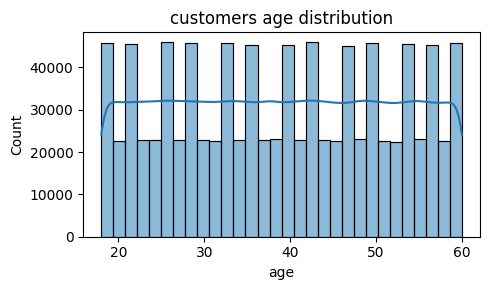

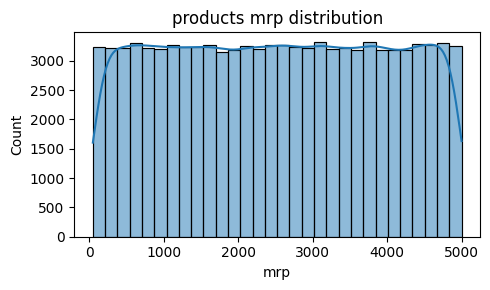

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
# 4) distributions for key numeric columns (histograms)
num_cols = {
    "customers": ["age"],
    "products": ["mrp"],  
}
for name, cols in num_cols.items():
    df = locals()[name]
    for c in cols:
        if c in df:
            plt.figure(figsize=(5, 3))
            sns.histplot(df[c].dropna(), kde=True, bins=30)
            plt.title(f"{name} {c} distribution")
            plt.tight_layout()
            plt.show()


Handling the missing value in *age* column and *mrp* column in **customer** table and **product** table respectively.

In [37]:
import pandas as pd
import numpy as np

# Example: customers = pd.read_csv("customers.csv")

# --- Step 0: define age range ---
min_age = int(customers['age'].min(skipna=True))
max_age = int(customers['age'].max(skipna=True))

# create 30 bins (same idea as MRP)
bins = np.linspace(min_age, max_age, 31)

labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# assign bins
customers['age_range'] = pd.cut(
    customers['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- Step 1: current distribution ---
bin_counts = customers['age_range'].value_counts().sort_index()

total_rows = len(customers)
missing_count = customers['age'].isna().sum()

target_per_bin = total_rows // len(labels)

# --- Step 2: needed per bin ---
needed_per_bin = target_per_bin - bin_counts
needed_per_bin = needed_per_bin.clip(lower=0)

# --- Step 3: generate values ---
filled_values = []

for i, label in enumerate(labels):
    n_needed = int(needed_per_bin.iloc[i])
    if n_needed > 0:
        low = bins[i]
        high = bins[i + 1]
        
        samples = np.random.uniform(low, high, n_needed)
        filled_values.extend(samples)

# handle leftover
remaining = missing_count - len(filled_values)
if remaining > 0:
    extra_samples = np.random.uniform(min_age, max_age, remaining)
    filled_values.extend(extra_samples)

np.random.shuffle(filled_values)

# --- Step 4: assign to missing ---
customers['age'] = customers['age'].astype(float)
customers.loc[customers['age'].isna(), 'age'] = filled_values[:missing_count]

# optional: round ages to integers
customers['age'] = customers['age'].round().astype(int)

# --- Step 5: recompute bins ---
customers['age_range'] = pd.cut(
    customers['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [38]:
import numpy as np

# Define bins
bins = np.linspace(0, 5100, 31)  # 30 ranges → 31 edges

# Create labels (optional, for readability)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# Create range column
products['mrp_range'] = pd.cut(products['mrp'], bins=bins, labels=labels, include_lowest=True)

In [39]:
# --- Step 1: count current distribution ---
bin_counts = products['mrp_range'].value_counts().sort_index()

# total rows and missing count
total_rows = len(products)
missing_count = products['mrp'].isna().sum()

# target per bin (equal distribution)
target_per_bin = total_rows // len(labels)

# --- Step 2: calculate how many values to add per bin ---
needed_per_bin = target_per_bin - bin_counts
needed_per_bin = needed_per_bin.clip(lower=0)  # no negatives

# --- Step 3: generate values for missing MRP ---
filled_values = []

for i, label in enumerate(labels):
    n_needed = int(needed_per_bin.iloc[i])
    if n_needed > 0:
        low = bins[i]
        high = bins[i + 1]
        
        # sample uniformly within the bin
        samples = np.random.uniform(low, high, n_needed)
        filled_values.extend(samples)

# If still missing due to rounding, fill remaining randomly
remaining = missing_count - len(filled_values)
if remaining > 0:
    extra_samples = np.random.uniform(0, 5100, remaining)
    filled_values.extend(extra_samples)

# shuffle to avoid order bias
np.random.shuffle(filled_values)

# --- Step 4: assign to missing rows ---
products.loc[products['mrp'].isna(), 'mrp'] = filled_values[:missing_count]

# --- Step 5: recompute bins after filling ---
products['mrp_range'] = pd.cut(products['mrp'], bins=bins, labels=labels, include_lowest=True)

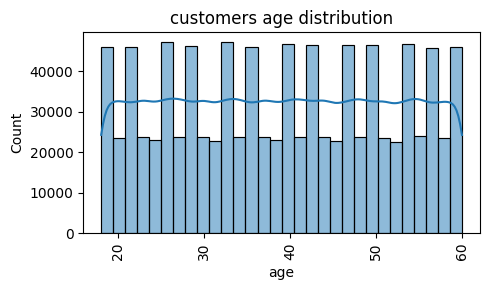

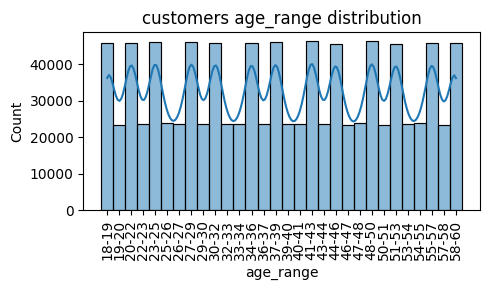

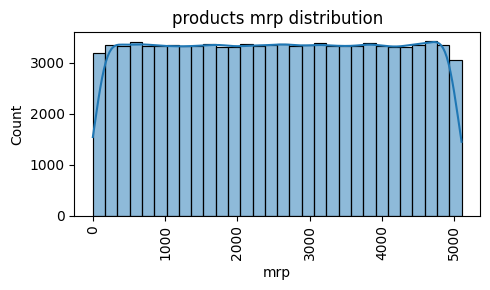

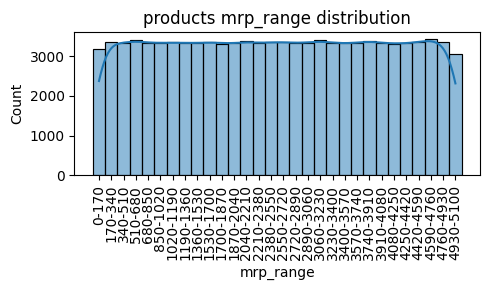

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
# 4) distributions for key numeric columns (histograms)
num_cols = {
    "customers": ["age", "age_range"],
    "products": ["mrp", "mrp_range"],  
}
for name, cols in num_cols.items():
    df = locals()[name]
    for c in cols:
        if c in df:
            plt.figure(figsize=(5, 3))
            sns.histplot(df[c].dropna(), kde=True, bins=30)
            plt.xticks(rotation=90)
            plt.title(f"{name} {c} distribution")
            plt.tight_layout()
            plt.show()

In [41]:
for name, df in [
    ("customers", customers),
    ("order_items", order_items),
    ("orders", orders),
    ("products", products),
]:
    print(f"{name} missing values:")
    print(df.isna().sum())
    print()

customers missing values:
customer_id    0
gender         0
first_name     0
last_name      0
full_name      0
age            0
city           0
signup_date    0
age_range      0
dtype: int64

order_items missing values:
order_id      0
product_id    0
quantity      0
unit_price    0
discount      0
net_amount    0
dtype: int64

orders missing values:
order_id          0
customer_id       0
order_date        0
order_ts          0
city              0
state             0
payment_method    0
order_status      0
total_amount      0
dtype: int64

products missing values:
product_id      0
brand           0
category        0
sub_category    0
mrp             0
mrp_range       0
dtype: int64



**All done!**

In [42]:
customers.head()                                                                                                                                                                                                                                                                                                                                                                                           

,customer_id,gender,first_name,last_name,full_name,age,city,signup_date,age_range
0,0,Female,Riya,Malhotra,Riya Malhotra,19,Pune,2024-09-30,18-19
1,1,Male,Suresh,Gupta,Suresh Gupta,27,Hyderabad,2025-11-13,26-27
2,2,Male,Amit,Reddy,Amit Reddy,37,Bangalore,2023-04-18,36-37
3,3,Male,Rohit,Malhotra,Rohit Malhotra,59,Pune,2024-12-28,58-60
4,4,Female,Neha,Iyer,Neha Iyer,56,Delhi,2024-08-19,55-57


In [43]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount,net_amount
0,Byk-0,6514,3,3614.06,275.99,10566.19
1,Byk-0,2222,4,4539.08,1090.19,17066.13
2,Byk-0,40137,4,85.64,12.91,329.65
3,Byk-1,48440,3,1384.96,317.69,3837.19
4,Byk-1,52122,1,3002.00,108.78,2893.22


In [44]:
orders.head()

,order_id,customer_id,order_date,order_ts,city,state,payment_method,order_status,total_amount
0,Byk-0,651198,2025-11-20,2025-11-20 16:38,Delhi,DL,Wallet,Cancelled,1755.48
1,Byk-1,192749,2025-12-07,2025-12-07 12:24,Pune,MH,Debit Card,Delivered,6055.63
2,Byk-2,217349,2025-04-10,2025-04-10 23:41,Chennai,TN,Credit Card,Delivered,1413.51
3,Byk-3,405295,2025-10-31,2025-10-31 13:24,Delhi,DL,COD,Delivered,3157.44
4,Byk-4,93506,2025-06-21,2025-06-21 19:14,Kolkata,WB,Debit Card,Delivered,4219.23


In [45]:
products.head()

,product_id,brand,category,sub_category,mrp,mrp_range
0,0,Nykaa Naturals,Makeup,Compact,4833.00,4760-4930
1,1,Lakme,Skincare,Serum,710.60,680-850
2,2,Nykaa Naturals,Makeup,Eyeliner,3217.86,3060-3230
3,3,WOW Skin Science,Personal Care,Sanitizer,4979.63,4930-5100
4,4,Lakme,Personal Care,Soap,347.29,340-510


In [46]:
data_dir = Path("../data/cleaned")  # relative to the notebook folder

# Create the directory if it doesn't exist
# data_dir.mkdir(parents=True, exist_ok=True)

# Save all cleaned data
customers.to_csv(data_dir / "customers.csv", index=False)
order_items.to_csv(data_dir / "order_items.csv", index=False)
orders.to_csv(data_dir / "orders.csv", index=False)
products.to_csv(data_dir / "products.csv", index=False)

print("All cleaned data saved successfully!")
print(f"Files saved to: {data_dir.resolve()}")

All cleaned data saved successfully!
Files saved to: /Users/shinle/Library/CloudStorage/OneDrive-Personal/FSU Activities/Machine Learning/Retail_Analytics/data/cleaned
